In [1]:
%matplotlib widget

import os

import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import random_split

import lolcat
from lolcat.nn import MLP, MultiHeadGlobalAttention, LOLCAT
from lolcat.ophys_dataset import OPhysDataset, OPhys4CellType
from lolcat.training import train_lolcat

C:\Users\ethan\AppData\Local\miniforge3\envs\lolcat\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [2]:
# load data and split into training and test sets
allen_data_dir = os.path.join(os.path.dirname(lolcat.__path__[0]), 'data')
stimuli = ['drifting_gratings']
concat = False
session_type = 'three_session_A'

allen_data = OPhysDataset(root=allen_data_dir, stimuli=stimuli, concat=concat, session_type=session_type).to('cuda')
train_data, test_data = random_split(allen_data, [0.7, 0.3])

filename \\proektdata.proektlab\LabData\code\CalciumImaging\lolcat\data\processed/drifting_gratings.pt


In [3]:
# create components of LOLCAT model
encoder = MLP((-1, 32, 16, 16, 16), batchnorm=True, dropout=0.5)
pool = MultiHeadGlobalAttention(in_channels=16, out_channels=16, heads=4)
classifier = MLP((-1, 8, len(OPhys4CellType)), dropout=0.5)

# as noted in the paper, initialize bias of last output layer proportional to class weights
model = LOLCAT(encoder, classifier, pool).to('cuda')

In [ ]:
loss_history = train_lolcat(
    model, train_set=train_data, test_set=test_data, cell_type_names=OPhys4CellType,
    batch_size=32, weighted=True, lr=1e-2, weight_decay=1e-5, epochs=300, use_early_stopping=True,
    early_stopping_patience=80, early_stopping_patience_inc=1e-5, set_classifier_bias_from_weights=True)

class weights: Pvalb=0.547351598739624, Vip=0.20863178372383118, Sst=0.24064597487449646, E=0.003370635909959674


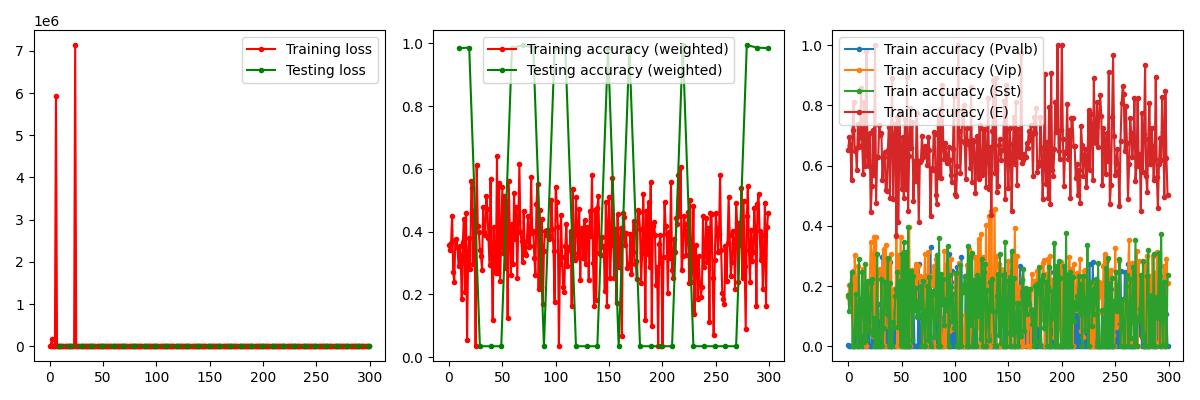

In [20]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].plot(loss_history['train_epoch'], loss_history['train_loss'], label='Training loss', marker='.', color='r')
axs[0].plot(loss_history['test_epoch'], loss_history['test_loss'], label='Testing loss', marker='.', color='g')
axs[0].legend()

axs[1].plot(loss_history['train_epoch'], loss_history['train_acc'], label='Training accuracy (weighted)', marker='.', color='r')
axs[1].plot(loss_history['test_epoch'], loss_history['test_acc'], label='Testing accuracy (weighted)', marker='.', color='g')
axs[1].legend()

for class_name, class_acc in zip(OPhys4CellType, np.array(loss_history['train_acc_per_class']).T):
    axs[2].plot(loss_history['train_epoch'], class_acc, label=f'Train accuracy ({class_name})', marker='.')
axs[2].legend()

fig.tight_layout()
plt.show()